In [1]:
import pandas as pd
import numpy as np

# DATASET INFORMATION #

## Input Variables (13 columns):
- crim: Per capita crime rate by town. Higher = more crime in that suburb.
- zn: Proportion of residential land zoned for lots over 25,000 sq. ft. Reflects low-density suburbs
- indus: Proportion of non-retail business acres per town (factories, warehouses). Higher = more industrial
- chas: Charles River dummy variable. 1 = tract borders the Charles River, 0 = does not. Riverside homes tend to be valued higher
- nox: Nitric oxide concentration (parts per 10 million). A proxy for air pollution — higher = more pollution, lower home values.
- rm: Average number of rooms per dwelling. Strongest positive predictor of home value — more rooms = higher price.
- age: Proportion (%) of owner-occupied units built before 1940. Higher = older neighbourhood stock.
- dis: Weighted distances to five Boston employment centres. Higher = farther from jobs.
- rad: Index of accessibility to radial highways (1–24). Higher = better highway access.
- tax: Full-value property tax rate per 10,000. Higher tax areas often overlap with industrial zones.
- lstat: Percentage of lower-status population. Strongest negative predictor — higher LSTAT, lower home value.
- medv: Median value of owner-occupied homes in 1,000s. This is what we tries to predict. Note: values are capped at $50k.

In [2]:
df = pd.read_csv('boston_housing.csv') 

In [3]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


# EDA #

<Axes: >

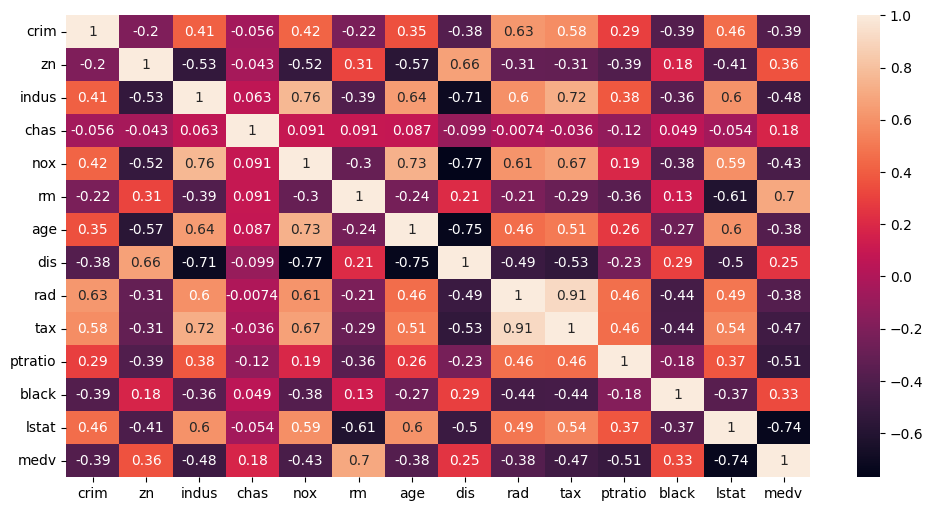

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot=True)

In [15]:
# Correlation btw medv and other 12 features 
corr_with_medv = df.corr()['medv'].sort_values(key = abs, ascending = False)
corr_with_medv

medv       1.000000
lstat     -0.737663
rm         0.695360
ptratio   -0.507787
indus     -0.483725
nox       -0.427321
crim      -0.388305
rad       -0.381626
age       -0.376955
zn         0.360445
black      0.333461
dis        0.249929
chas       0.175260
Name: medv, dtype: float64

Lstat and Room has the biggest correlations with medv 

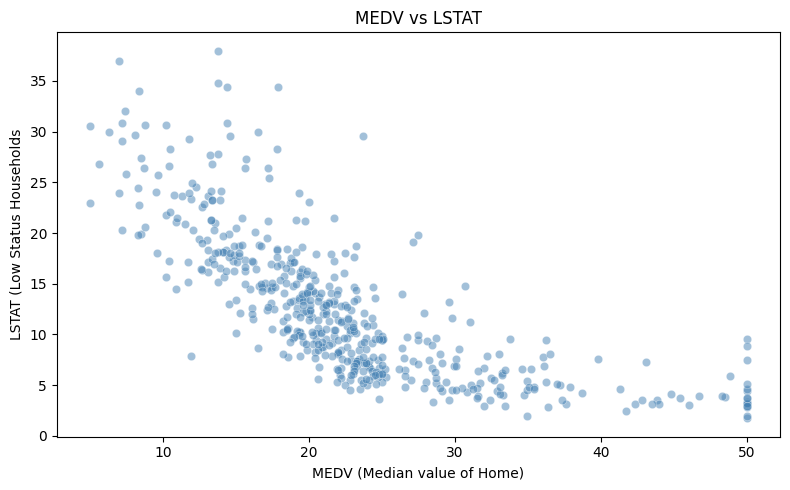

In [7]:
# Correlation between medv and Lstat
plt.figure(figsize = (8,5)) 
plt.scatter(df['medv'],df['lstat'], alpha = 0.5, color = 'steelblue',edgecolors='white', linewidths=0.4)
plt.xlabel('MEDV (Median value of Home)')
plt.ylabel('LSTAT (Low Status Households') 
plt.title('MEDV vs LSTAT')
plt.tight_layout()
plt.show()

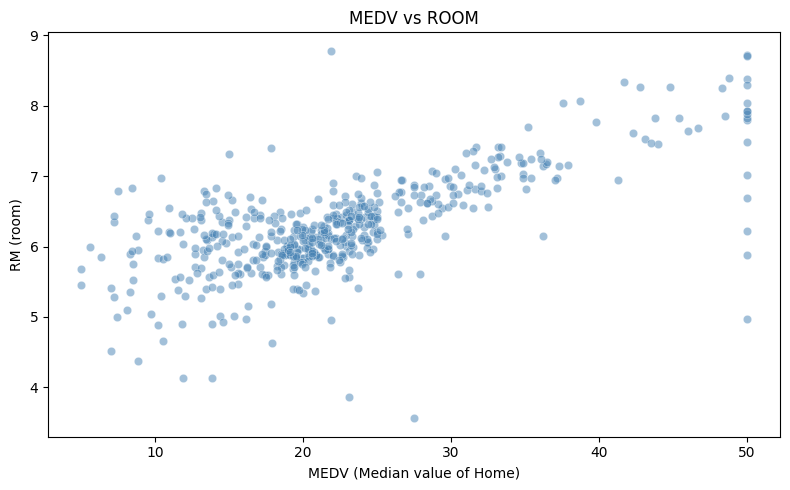

In [8]:
# Correlation between medv and Room 
plt.figure(figsize = (8,5))
plt.scatter(x=df['medv'],y=df['rm'], alpha = 0.5, color = 'steelblue',edgecolors='white', linewidths=0.4)
plt.xlabel('MEDV (Median value of Home)')
plt.ylabel('RM (room)') 
plt.title('MEDV vs ROOM')
plt.tight_layout()
plt.show()

In [9]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df.drop(columns= ['medv'],inplace = False) 
X = sm.add_constant(X)  # add this line

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop the constant row before viewing results
vif_data = vif_data[vif_data['feature'] != 'const']
print(vif_data.sort_values('VIF', ascending=False))
#VIF = 1/(1-R^2i) --> to show how well I can predict a feature depends on other features

    feature       VIF
10      tax  9.008554
9       rad  7.484496
5       nox  4.393720
3     indus  3.991596
8       dis  3.955945
7       age  3.100826
13    lstat  2.941491
2        zn  2.298758
6        rm  1.933744
11  ptratio  1.799084
1      crim  1.792192
12    black  1.348521
4      chas  1.073995


## Feature Engineering

In [10]:
df.drop(columns='tax',inplace=True) 

In [11]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,21.0,393.45,6.48,22.0


## Split the Dataset

In [79]:
X = df.iloc[:,:-1] 
y = df.iloc[:,-1]

In [80]:
X

,crim,indus,chas,nox,rm,dis,rad,ptratio,black,lstat
0,0.00632,2.31,0,0.538,6.575,4.0900,1,15.3,396.90,4.98
1,0.02731,7.07,0,0.469,6.421,4.9671,2,17.8,396.90,9.14
2,0.02729,7.07,0,0.469,7.185,4.9671,2,17.8,392.83,4.03
3,0.03237,2.18,0,0.458,6.998,6.0622,3,18.7,394.63,2.94
4,0.06905,2.18,0,0.458,7.147,6.0622,3,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...
501,0.06263,11.93,0,0.573,6.593,2.4786,1,21.0,391.99,9.67
502,0.04527,11.93,0,0.573,6.120,2.2875,1,21.0,396.90,9.08
503,0.06076,11.93,0,0.573,6.976,2.1675,1,21.0,396.90,5.64
504,0.10959,11.93,0,0.573,6.794,2.3889,1,21.0,393.45,6.48


In [81]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64

In [82]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25, random_state = 42) 

<Axes: xlabel='medv', ylabel='lstat'>

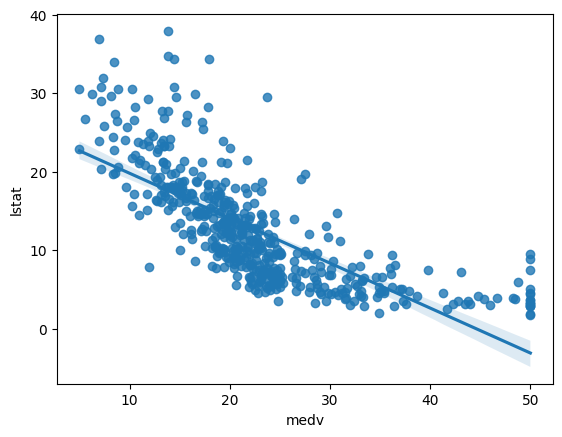

In [83]:
import seaborn as sns 
sns.regplot(x=df['medv'],y=df['lstat']) 

## Feature scaling 

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

## Train a model

In [85]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [86]:
model.coef_

array([-1.03094493, -0.10094504,  0.79806706, -2.1795401 ,  3.19496323,
       -2.53079875,  1.10549254, -2.31968941,  1.16499178, -3.72392654])

In [87]:
# See what the model learned
import pandas as pd
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

   feature  coefficient
9    lstat    -3.723927
4       rm     3.194963
5      dis    -2.530799
7  ptratio    -2.319689
3      nox    -2.179540
8    black     1.164992
6      rad     1.105493
0     crim    -1.030945
2     chas     0.798067
1    indus    -0.100945


In [97]:
import statsmodels.api as sm
import pandas as pd

# convert scaled array back to dataframe with column names
X_train_const = sm.add_constant(pd.DataFrame(X_train_scaled, columns=X_train.columns))

ols = sm.OLS(y_train.values, X_train_const).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     106.5
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          3.84e-102
Time:                        23:12:28   Log-Likelihood:                -1130.1
No. Observations:                 379   AIC:                             2282.
Df Residuals:                     368   BIC:                             2326.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.9079      0.249     92.070      0.000      22.419      23.397
crim          -1.0309      0.327     -3.150      0.002      -1.674      -0.387
indus         -0.1009      0.447     -0.226      0.821      -0.979       0.777
chas           0.7981      0.259      3.084      0.002       0.289       1.307
nox           -2.1795      0.509     -4.280      0.000      -3.181      -1.178
rm             3.1950      0.339      9.437      0.000       2.529       3.861
dis           -2.5308      0.419     -6.044      0.000      -3.354      -1.707
rad            1.1055      0.414      2.673      0.008       0.292       1.919
ptratio       -2.3197      0.318     -7.290      0.000      -2.945      -1.694
black          1.1650      0.279      4.173      0.000       0.616       1.714
lstat         -3.7239      0.396     -9.400      0.000      -4.503      -2.945
==============================================================================
Omnibus:                      119.351   Durbin-Watson:                   2.118
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              480.866
Skew:                           1.330   Prob(JB):                    3.81e-105
Kurtosis:                       7.835   Cond. No.                         5.27
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Here, we see: 
- zn,indus and age has p value < 0.5 => statistically insignificant
- age and indus has low coef
==> try to drop age and indus columns 

## Evaluate a model 

In [88]:
#Cross validation to check if the model is stable or I just get lucky with high r2 
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring = 'r2')
print(np.mean(validation_score))

0.713830872662659


In [89]:
## prediction 
y_pred = model.predict(X_test_scaled)  

In [90]:
## performance metric
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)  
rmse = np.sqrt(mse) 
print(mse) 
print(mae)
print(rmse) 

23.68081758400665
3.169827112633811
4.866294029752687


In [91]:
from sklearn.metrics import r2_score 
score = r2_score(y_test, y_pred) 
print(score)

0.661833735488127


## Assumptions

1. Linear relationship

y_test and y_pred should follow a LINEAR trend

→ checked by: scatter plot of y_test vs y_pred

→ dots should follow the diagonal red line

2. Normality of residuals

residuals should be normally distributed centered at 0

→ checked by: KDE plot (your displot)

→ should look like a bell curve peaking at 0

3. Homoscedasticity

residuals should be RANDOMLY and UNIFORMLY scattered around 0

→ checked by: residual vs y_pred scatter plot

→ should have no pattern, no funnel shape

4. No multicollinearity

features should NOT be highly correlated with each other

→ checked by: correlation heatmap

→ age and lstat being correlated = violation

→ checked by: OLS p-values

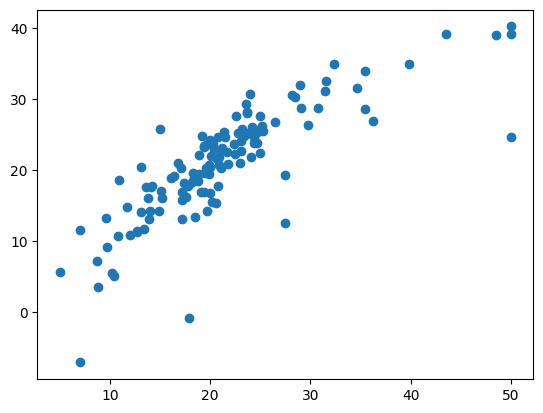

In [92]:
plt.scatter(y_test,y_pred)

There is a linear relationship, but the model struggles with high value and low value homes, suggest non-linear relationship that LinearRegression cannot capture. 

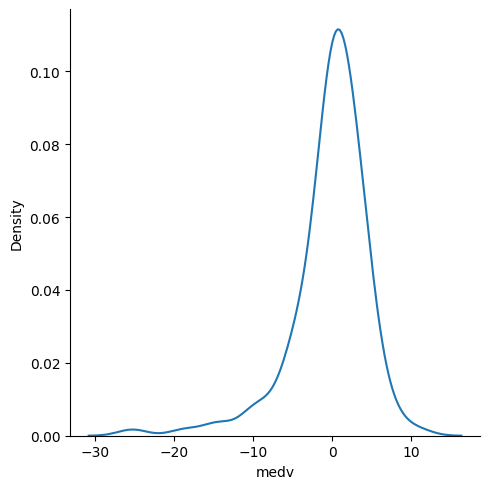

In [93]:
residuals = y_pred-y_test 
sns.displot(residuals,kind = 'kde') 

- Peak at 0: model is unbiased on average => most predictions are very close to correct
- Long left tail indicates that there was huge gap bwt the predicted and truth values => the model can be unreliable

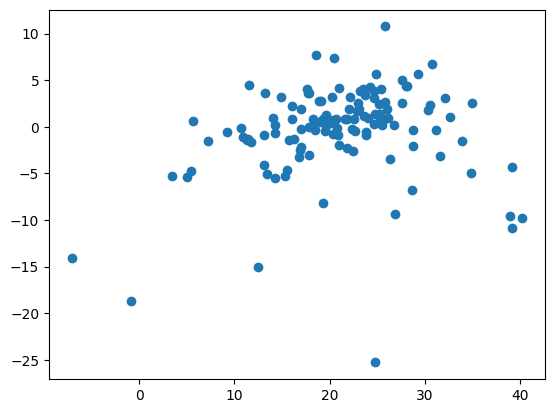

In [99]:
# PLOT THE RESIDUALS OF EACH Y_PRED 
plt.scatter(y_pred,residuals) 

Medium price homes (15k–30k) → model guesses pretty close → small errors → dots near 0 in the middle of your plot ✅

Very cheap homes (near 0) → model guesses way too high → huge errors → dots at -15, -19 on the left of your plot ❌

Very expensive homes (40k+) → model also struggles → errors getting bigger on the right ❌